In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import allanself
import scipy
import glob


# Import and plot data (with FCN)

In [2]:
def process_data(data_txt):
    # Read data
    cols = ['MJD', 'dX', 'sigma_dX', 'dY', 'sigma_dY']
    cols_widths = [(0,11),(12,22),(23,33),(34,44),(45,55)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=1, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna() 

    return df_new

In [3]:
df = process_data('nut_opa.dat')

In [4]:
len(df)

5311

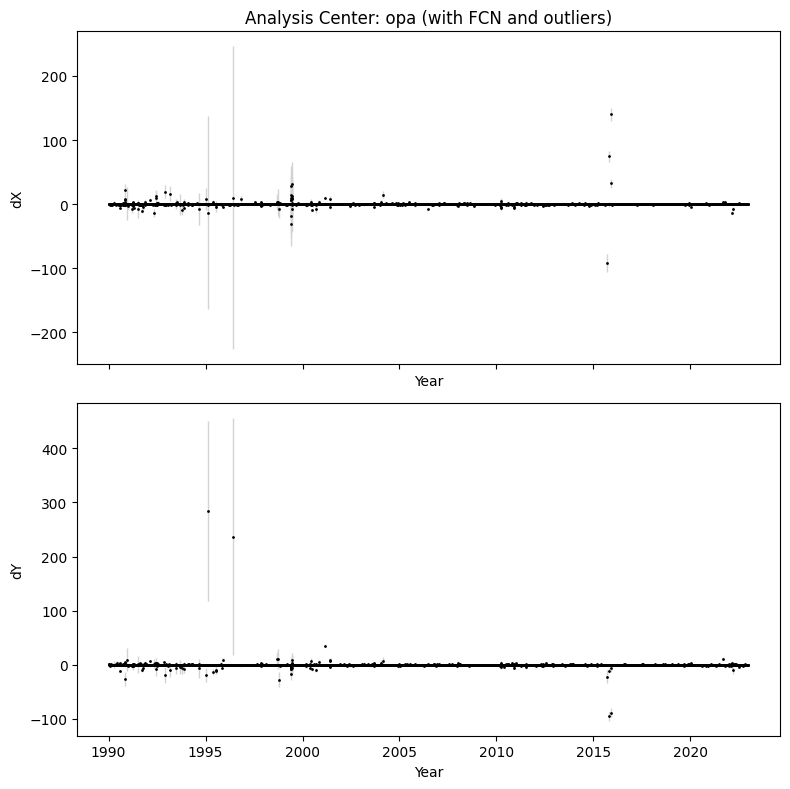

In [5]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes = axes.flatten()

# Plot dX
axes[0].errorbar(2000 - (51544.333981 - df['MJD']) / 365.242198781, df['dX'], yerr=df['sigma_dX'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[0].set_title(f'Analysis Center: opa (with FCN and outliers)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('dX')


# Plot dY
axes[1].errorbar(2000 - (51544.333981 - df['MJD']) / 365.242198781, df['dY'], yerr=df['sigma_dY'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[1].set_xlabel('Year')
axes[1].set_ylabel('dY')

plt.tight_layout()
plt.show()

In [6]:
def remove_outliers(df,datatype):
    if datatype == 'dX':
        df_sel = df[['MJD','dX','sigma_dX']].copy()
        datas = 'dX'
        datas_e = 'sigma_dX'
    elif datatype == 'dY':
        df_sel = df[['MJD','dY','sigma_dY']].copy()
        datas = 'dY'
        datas_e = 'sigma_dY'
    else:
        print('Please choose dX/dY data')

    for index, row in df_sel.iterrows():
        data_values = df_sel[(df_sel['MJD'] >= (row['MJD'] - 365)) & (df_sel['MJD'] <= (row['MJD'] + 365))]
        wd = 1/data_values[datas_e].values**2
        mean = np.average(data_values[datas],weights=wd)
        std = np.sqrt(allanself.wvar(data_values[datas].values,wd))
        if abs(row[datas] - mean) > 6*std:
            df_sel.drop(index, inplace = True)
    return df_sel

In [7]:
df_dX = remove_outliers(df,'dX')

In [8]:
len(df_dX)

5152

In [9]:
df_dY = remove_outliers(df,'dY')
len(df_dY)

5146

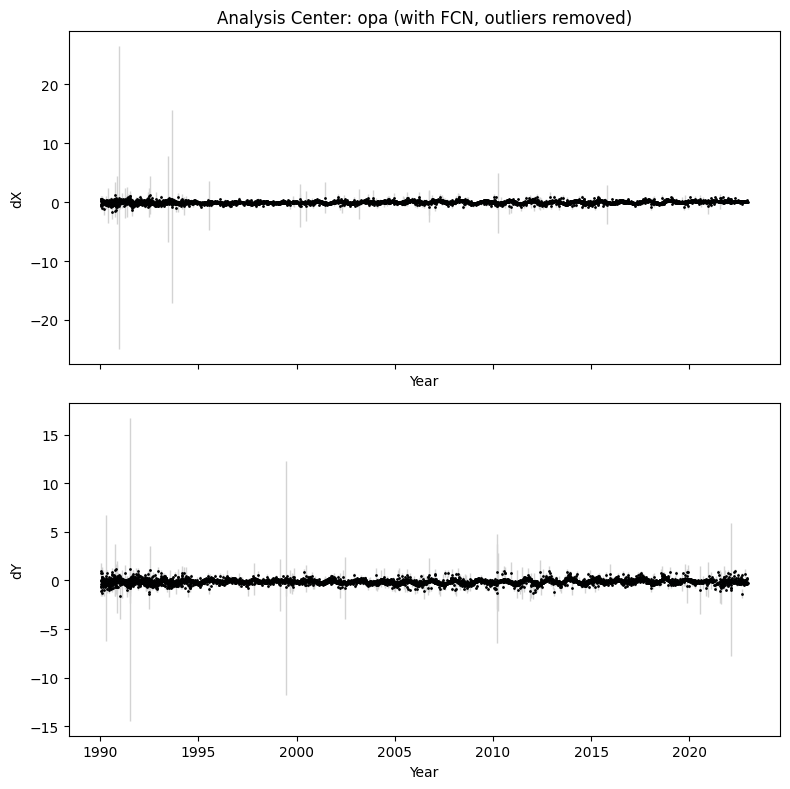

In [10]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes = axes.flatten()

# Plot dX
axes[0].errorbar(2000 - (51544.333981 - df_dX['MJD']) / 365.242198781, df_dX['dX'], yerr=df_dX['sigma_dX'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[0].set_title(f'Analysis Center: opa (with FCN, outliers removed)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('dX')


# Plot dY
axes[1].errorbar(2000 - (51544.333981 - df_dY['MJD']) / 365.242198781, df_dY['dY'], yerr=df_dY['sigma_dY'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[1].set_xlabel('Year')
axes[1].set_ylabel('dY')

plt.tight_layout()
plt.show()

# Allan std dev - with FNC

In [11]:
%%time
tau_dX, allanstd_dX = allanself.oadev(df_dX['dX'].values,df_dX['MJD'].values,df_dX['sigma_dX'].values)

CPU times: total: 33min 48s
Wall time: 15h 26min 21s


In [12]:
%%time
tau_dY, allanstd_dY = allanself.oadev(df_dY['dY'].values,df_dY['MJD'].values,df_dY['sigma_dY'].values)

CPU times: total: 54min
Wall time: 1h 16min 33s


In [13]:
ci_dX_low, ci_dX_high = allanself.confidence_int(df_dX['dX'].values,df_dX['sigma_dX'].values,allanstd_dX,modified=False,overlapping=True,devtype='allan')

In [14]:
ci_dY_low, ci_dY_high = allanself.confidence_int(df_dY['dY'].values,df_dY['sigma_dY'].values,allanstd_dY,modified=False,overlapping=True,devtype='allan')

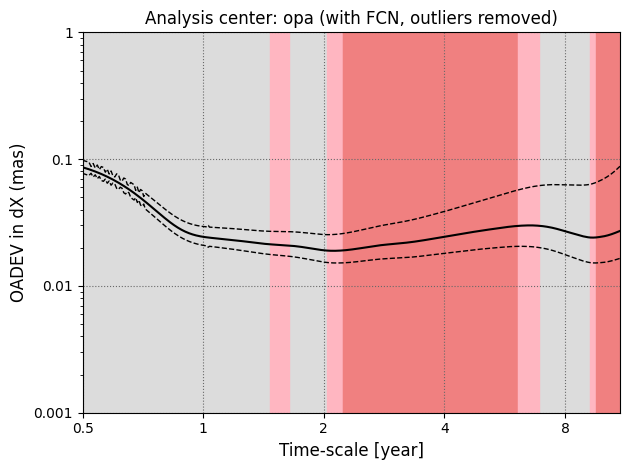

In [15]:
plt.figure()
# Calculate the slopes
slopes_dX = np.diff(np.log10(allanstd_dX)) / np.diff(np.log10(tau_dX))
tau_dX_year = [t/365.242198781 for t in tau_dX]
# Plot allanstd

plt.plot(tau_dX_year,allanstd_dX,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dX_year[1:], 0, 10**5, where= (slopes_dX < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_dX_year[1:], 0, 10**5, where= (-0.25 <= slopes_dX) & (slopes_dX <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_dX_year[1:], 0, 10**5, where= (slopes_dX > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_dX_year, ci_dX_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dX_year, ci_dX_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dX (mas)', fontsize=12)
plt.title('Analysis center: opa (with FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_dX_year))
plt.tight_layout()

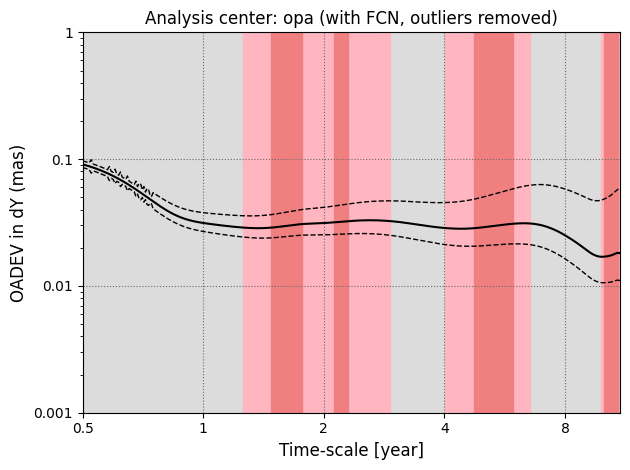

In [16]:
plt.figure()
# Calculate the slopes
slopes_dY = np.diff(np.log10(allanstd_dY)) / np.diff(np.log10(tau_dY))
tau_dY_year = [t/365.242198781 for t in tau_dY]
# Plot allanstd

plt.plot(tau_dY_year,allanstd_dY,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dY_year[1:], 0, 10**5, where= (slopes_dY < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_dY_year[1:], 0, 10**5, where= (-0.25 <= slopes_dY) & (slopes_dY <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_dY_year[1:], 0, 10**5, where= (slopes_dY > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_dY_year, ci_dY_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dY_year, ci_dY_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dY (mas)', fontsize=12)
plt.title('Analysis center: opa (with FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_dY_year))
plt.tight_layout()

# Removing FCN

In [17]:
def process_fcn(fcn_txt):
    # Read data
    cols = ['MJD', 'X', 'Y', 'sigma_X', 'sigma_Y']
    cols_widths = [(0,11),(12,21),(22,31),(32,41),(42,51)]
    df = pd.read_fwf(fcn_txt, colspecs=cols_widths, skiprows=1, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna() 

    return df_new

In [18]:
fcn_opa = process_fcn('fcn_opa.txt')
fcn_opa.head(5)

,MJD,X,Y,sigma_X,sigma_Y
0,44089.99,235.04,-161.78,169.52,169.52
1,44203.21,-187.27,-179.84,154.16,154.16
2,44341.68,-90.81,252.91,137.15,137.15
3,44446.52,267.08,154.84,125.62,125.62
4,44447.45,269.33,151.67,125.52,125.52


In [19]:
fcn_opa[['X','Y','sigma_X','sigma_Y']] = fcn_opa[['X','Y','sigma_X','sigma_Y']] / 1000
fcn_opa.head(5)

,MJD,X,Y,sigma_X,sigma_Y
0,44089.99,0.23504,-0.16178,0.16952,0.16952
1,44203.21,-0.18727,-0.17984,0.15416,0.15416
2,44341.68,-0.09081,0.25291,0.13715,0.13715
3,44446.52,0.26708,0.15484,0.12562,0.12562
4,44447.45,0.26933,0.15167,0.12552,0.12552


In [20]:
df_dX.head(5)

,MJD,dX,sigma_dX
0,47904.262,0.455,0.102
1,47908.173,0.547,0.460
2,47909.232,-0.452,0.173
3,47910.339,0.239,0.115
4,47912.163,-0.693,0.390


In [21]:
df_dX['MJD_int'] = df_dX['MJD'].astype(int)
df_dY['MJD_int'] = df_dY['MJD'].astype(int)
fcn_opa['MJD_int'] = fcn_opa['MJD'].astype(int)

In [22]:
merged_dX = pd.merge(df_dX, fcn_opa, on='MJD_int', how='inner')
merged_dX.head(5)


,MJD_x,dX,sigma_dX,MJD_int,MJD_y,X,Y,sigma_X,sigma_Y
0,47904.262,0.455,0.102,47904,47904.26,0.16189,-0.03172,0.01823,0.01823
1,47908.173,0.547,0.460,47908,47908.17,0.15961,-0.04111,0.01820,0.01820
2,47909.232,-0.452,0.173,47909,47909.23,0.15890,-0.04363,0.01819,0.01819
3,47909.232,-0.452,0.173,47909,47909.25,0.15889,-0.04367,0.01819,0.01819
4,47910.339,0.239,0.115,47910,47910.34,0.15812,-0.04625,0.01818,0.01818


In [23]:
merged_dX = merged_dX.drop(['MJD_int', 'MJD_y','Y','sigma_Y'], axis=1)


In [24]:
merged_dX.rename(columns={'MJD_x': 'MJD'}, inplace=True)
merged_dX.head(5)

,MJD,dX,sigma_dX,X,sigma_X
0,47904.262,0.455,0.102,0.16189,0.01823
1,47908.173,0.547,0.460,0.15961,0.01820
2,47909.232,-0.452,0.173,0.15890,0.01819
3,47909.232,-0.452,0.173,0.15889,0.01819
4,47910.339,0.239,0.115,0.15812,0.01818


In [25]:
merged_dX['dXnoFCN'] = merged_dX['dX'] - merged_dX['X'] 
merged_dX['sigmanoFCN'] = abs(merged_dX['sigma_dX'] - merged_dX['sigma_X']) 
merged_dX.head(5)

,MJD,dX,sigma_dX,X,sigma_X,dXnoFCN,sigmanoFCN
0,47904.262,0.455,0.102,0.16189,0.01823,0.29311,0.08377
1,47908.173,0.547,0.460,0.15961,0.01820,0.38739,0.44180
2,47909.232,-0.452,0.173,0.15890,0.01819,-0.61090,0.15481
3,47909.232,-0.452,0.173,0.15889,0.01819,-0.61089,0.15481
4,47910.339,0.239,0.115,0.15812,0.01818,0.08088,0.09682


In [26]:
merged_dY = pd.merge(df_dY, fcn_opa, on='MJD_int', how='inner')
merged_dY.head(5)


,MJD_x,dY,sigma_dY,MJD_int,MJD_y,X,Y,sigma_X,sigma_Y
0,47904.262,-0.059,0.110,47904,47904.26,0.16189,-0.03172,0.01823,0.01823
1,47908.173,0.929,0.867,47908,47908.17,0.15961,-0.04111,0.01820,0.01820
2,47909.232,0.790,0.346,47909,47909.23,0.15890,-0.04363,0.01819,0.01819
3,47909.232,0.790,0.346,47909,47909.25,0.15889,-0.04367,0.01819,0.01819
4,47910.339,0.022,0.166,47910,47910.34,0.15812,-0.04625,0.01818,0.01818


In [27]:
merged_dY = merged_dY.drop(['MJD_int', 'MJD_y','X','sigma_X'], axis=1)
merged_dY.rename(columns={'MJD_x': 'MJD'}, inplace=True)
merged_dY['dYnoFCN'] = merged_dY['dY'] - merged_dY['Y'] 
merged_dY['sigmanoFCN'] = abs(merged_dY['sigma_dY'] - merged_dY['sigma_Y']) 
merged_dY.head(5)

,MJD,dY,sigma_dY,Y,sigma_Y,dYnoFCN,sigmanoFCN
0,47904.262,-0.059,0.110,-0.03172,0.01823,-0.02728,0.09177
1,47908.173,0.929,0.867,-0.04111,0.01820,0.97011,0.84880
2,47909.232,0.790,0.346,-0.04363,0.01819,0.83363,0.32781
3,47909.232,0.790,0.346,-0.04367,0.01819,0.83367,0.32781
4,47910.339,0.022,0.166,-0.04625,0.01818,0.06825,0.14782


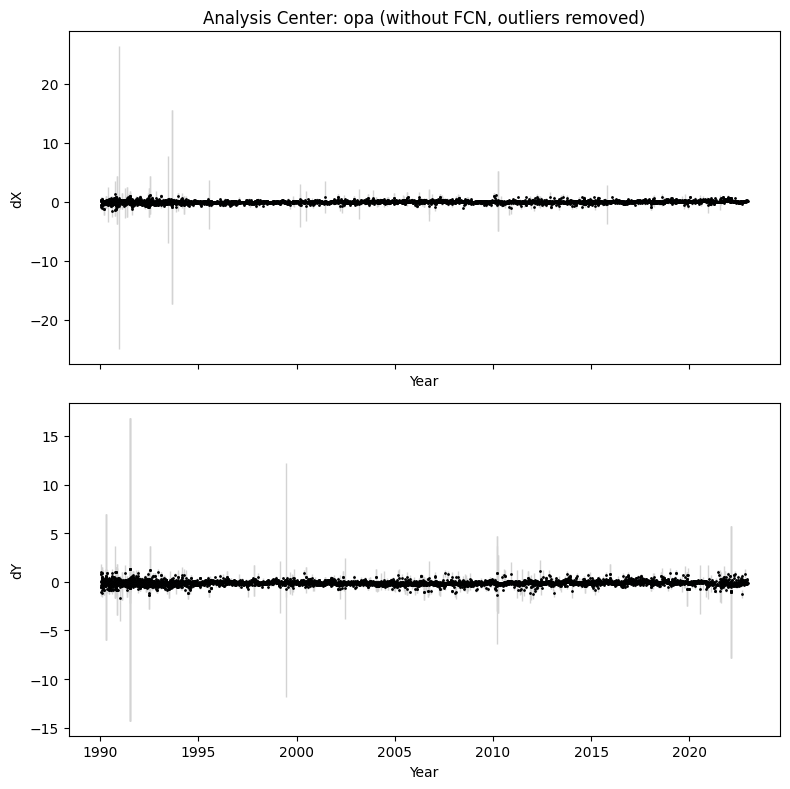

In [28]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes = axes.flatten()

# Plot dX
axes[0].errorbar(2000 - (51544.333981 - merged_dX['MJD']) / 365.242198781, merged_dX['dXnoFCN'], yerr=merged_dX['sigmanoFCN'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[0].set_title(f'Analysis Center: opa (without FCN, outliers removed)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('dX')


# Plot dY
axes[1].errorbar(2000 - (51544.333981 - merged_dY['MJD']) / 365.242198781, merged_dY['dYnoFCN'], yerr=merged_dY['sigmanoFCN'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[1].set_xlabel('Year')
axes[1].set_ylabel('dY')

plt.tight_layout()
plt.show()

# Allan std dev - no FCN

In [29]:
%%time
tau_noFCN_dX, allanstd_noFCN_dX = allanself.oadev(merged_dX['dXnoFCN'].values,merged_dX['MJD'].values,merged_dX['sigmanoFCN'].values)

CPU times: total: 1h 9min 3s
Wall time: 4h 54min 51s


In [30]:
%%time
tau_noFCN_dY, allanstd_noFCN_dY = allanself.oadev(merged_dY['dYnoFCN'].values,merged_dY['MJD'].values,merged_dY['sigmanoFCN'].values)

CPU times: total: 1h 8min 30s
Wall time: 1h 39min 45s


In [31]:
ci_noFCN_dX_low, ci_noFCN_dX_high = allanself.confidence_int(merged_dX['dXnoFCN'].values,merged_dX['sigmanoFCN'].values,allanstd_noFCN_dX,modified=False,overlapping=True,devtype='allan')
ci_noFCN_dY_low, ci_noFCN_dY_high = allanself.confidence_int(merged_dY['dYnoFCN'].values,merged_dY['sigmanoFCN'].values,allanstd_noFCN_dY,modified=False,overlapping=True,devtype='allan')

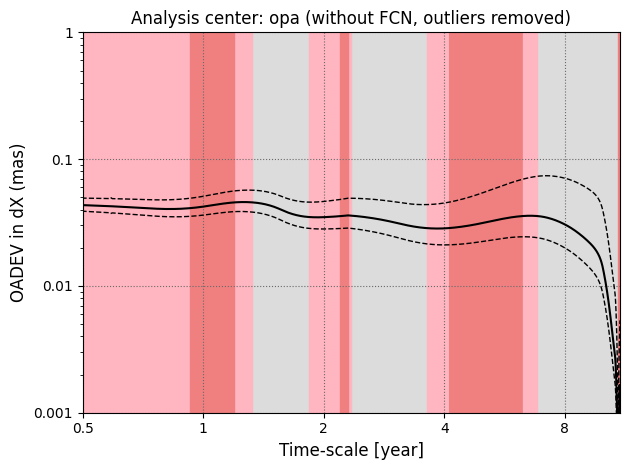

In [32]:
plt.figure()
# Calculate the slopes
slopes_noFCN_dX = np.diff(np.log10(allanstd_noFCN_dX)) / np.diff(np.log10(tau_noFCN_dX))
tau_noFCN_dX_year = [t/365.242198781 for t in tau_noFCN_dX]
# Plot allanstd

plt.plot(tau_noFCN_dX_year,allanstd_noFCN_dX,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_noFCN_dX_year[1:], 0, 10**5, where= (slopes_noFCN_dX < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_noFCN_dX_year[1:], 0, 10**5, where= (-0.25 <= slopes_noFCN_dX) & (slopes_noFCN_dX <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_noFCN_dX_year[1:], 0, 10**5, where= (slopes_noFCN_dX > 0.25),color='lightcoral',step='mid',linewidth=1)
# Plot confidence interval
plt.plot(tau_noFCN_dX_year, ci_noFCN_dX_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_noFCN_dX_year, ci_noFCN_dX_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dX (mas)', fontsize=12)
plt.title('Analysis center: opa (without FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_noFCN_dX_year))
plt.tight_layout()

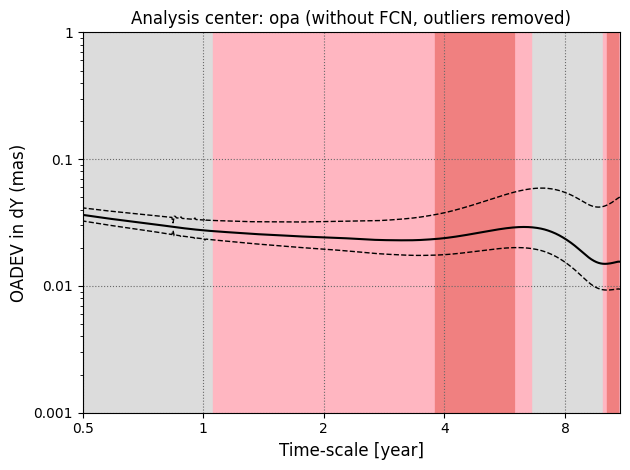

In [33]:
plt.figure()
# Calculate the slopes
slopes_noFCN_dY = np.diff(np.log10(allanstd_noFCN_dY)) / np.diff(np.log10(tau_noFCN_dY))
tau_noFCN_dY_year = [t/365.242198781 for t in tau_noFCN_dY]
# Plot allanstd

plt.plot(tau_noFCN_dY_year,allanstd_noFCN_dY,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_noFCN_dY_year[1:], 0, 10**5, where= (slopes_noFCN_dY < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_noFCN_dY_year[1:], 0, 10**5, where= (-0.25 <= slopes_noFCN_dY) & (slopes_noFCN_dY <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_noFCN_dY_year[1:], 0, 10**5, where= (slopes_noFCN_dY > 0.25),color='lightcoral',step='mid',linewidth=1)
# Plot confidence interval
plt.plot(tau_noFCN_dY_year, ci_noFCN_dY_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_noFCN_dY_year, ci_noFCN_dY_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dY (mas)', fontsize=12)
plt.title('Analysis center: opa (without FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_noFCN_dY_year))
plt.tight_layout()